# Developing the Agent logic

The whole point of the project is to find a way to use the differences of
performance which have proven to maybe be useful.

The steps to follow are according to the logical order of training with replay
buffer

0. Preparation for buffer (indexing and data-structure)
1. Feeding "forward pass" - including a simple actor
2. Sampling
3. training logic with buffer

In [1]:
import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)


from thesis.helper_scripts.general import extract_objs_from_sim_dir
from thesis.helper_scripts.hypothesis_visualization import simulation_counts_per_round

from berebasl.simulation.credit_data_simulation import CreditData, CreditDataSample


sim_objs = extract_objs_from_sim_dir(
    grid_path='../berebasl/data/simulations/mnar_grid_hyp_testing',
    sim_dir='bias_0_0_corr_0_2',
    device=torch.device('cpu')
)

In [2]:
from typing import Literal, Dict
from copy import deepcopy
from matplotlib import pyplot as plt
from math import prod

from typing import Optional

class CreditDataManager:
    def __init__(
            self,
            sim_objs: dict,
            wished_acc_base: Literal["roc", "ks"]
        ):
        self.credit_data: CreditData = deepcopy(sim_objs["credit_data"])
        self.wished_acc_base = wished_acc_base
        key_wanted_acc = "acc_based_" + wished_acc_base
        alternative_accepted = sim_objs["alternative_accepted"]
        if key_wanted_acc in alternative_accepted:
            self.credit_data.change_acceptance_flag(alternative_accepted[key_wanted_acc])

        model_vars  = [
            f for f in range(self.credit_data.features_count) if f != sim_objs["var_to_hide"]
        ]  # visible features
        self.credit_data.features = self.credit_data.features[..., model_vars]

        counts, th_meaning = simulation_counts_per_round(sim_objs)
        idx_wanted = [i for i, k in enumerate(th_meaning) if k == key_wanted_acc]
        assert len(idx_wanted) == 1
        idx_wanted = idx_wanted[0]

        self.counts: torch.Tensor = counts[idx_wanted] # [AR, TBG, G]
        self.cumsum_counts = self.counts.cumsum(dim=-1)

    @property
    def N_acc(self):
        return self.credit_data.count_accepts
    
    @property
    def N_rej(self):
        return self.credit_data.count_rejects
    
    @property
    def N(self):
        return self.credit_data.count_all
    
    @property
    def F(self):
        return self.credit_data.features_count

    @property
    def mask_gens_with_defaults(self):
        return self.counts[0, 1] > 0
    
    @property
    def device(self):
        return self.credit_data.device

    def plot_defaults_among_acc(self, title: str= '') -> None:
        accepted_defaults = self.counts[0, 1, 1:].cpu()
        rounds = torch.arange(1, self.credit_data.last_gen_round+1, device=accepted_defaults.device)

        mask_was_zero = accepted_defaults==0

        plt.plot(rounds, accepted_defaults, label="Defaults count")
        plt.scatter(rounds[mask_was_zero], accepted_defaults[mask_was_zero], s=5, c='red', label="Points with Zero Defaults")

        plt.ylabel("Defaults among accepts")
        plt.xlabel("Generation round")

        plt.legend()
        plt.show()

    def get_round_ids_with_no_defaults_among_acc(self) -> torch.Tensor:
        accepted_defaults = self.counts[0, 1]
        rounds = torch.arange(0, self.credit_data.last_gen_round+1, device=accepted_defaults.device)
        return rounds[accepted_defaults==0]

    def set_maximal_gen_round(self, gen_round: int):
        if not (0 <= gen_round <= self.credit_data.last_gen_round):
            raise AssertionError(f"gen_round has to be between 0 and self.credit_data.last_gen_round={self.credit_data.last_gen_round}")
        
        mask_keep = self.credit_data.gen_round <= gen_round

        attr_to_cut_of_cred_data = ["features", "default_flag", "accepted", "gen_round"]
        for a in attr_to_cut_of_cred_data:
            setattr(self.credit_data, a, getattr(self.credit_data, a)[mask_keep])

        self.credit_data.change_acceptance_flag(self.credit_data.accepted)
        self.counts = self.counts[..., :gen_round+1]
        self.cumsum_counts = self.cumsum_counts[..., :gen_round+1]

    def generate_credit_sample(self, up_to_gen: torch.Tensor, from_gen: Optional[torch.Tensor] = None) -> CreditDataSample:
        if from_gen is None:
            from_gen = torch.zeros_like(up_to_gen)
        
        min_gen = from_gen.min()
        max_gen = up_to_gen.max()
        batch_shape = up_to_gen.shape

        padded_cumsums = nn.functional.pad(self.cumsum_counts, (1,1), value=0)
        counts_to_fetch = padded_cumsums[..., 0, up_to_gen+1] - padded_cumsums[..., 0, from_gen] # [AR, *batch_shape]

        max_acc, max_rej =counts_to_fetch.flatten(start_dim=1).max(dim=-1).values # [AR] # The totals
        
        F = self.F
        feats_rej_buffer = self.credit_data.features.new_full( # [*batch_dims, n_r+1, F]
            batch_shape + torch.Size([max_rej+1, F]),
            fill_value=float('nan')
        )
        feats_acc_buffer = feats_rej_buffer.new_full( # [*batch_dims, n_a+1, F]
            batch_shape + torch.Size([max_acc+1, F]),
            fill_value=float('nan')
        )
        lbls_buffer = self.credit_data.default_flag.new_full( # [*batch_dims, n_a+1, F]
            batch_shape + torch.Size([max_acc+1]),
            fill_value=float('nan')
        )

        # n = n_a + n_r
        max_acc_cross_batch, max_rej_cross_batch = self.cumsum_counts[..., 0, max_gen] - padded_cumsums[..., 0, min_gen]
        n = max_acc_cross_batch + max_rej_cross_batch
        arange_n = torch.arange(n, device=feats_rej_buffer.device)
        arange_n_a = arange_n[:max_acc_cross_batch]
        arange_n_r = arange_n[:max_rej_cross_batch]

        #[n, F], [n], [n], [n],
        feats, lbls, gen_round, mask_acc = self.credit_data.unbiased_obs(
            include_gen_round=True,
            include_accepted_status=True,
            from_round_idx=min_gen,
            up_to_round_idx=max_gen
        )
        mask_rej = ~mask_acc

        batch_shape_as_ones = (1,) * len(batch_shape)

        #print(from_gen.shape,gen_round.view(*batch_shape_as_ones, max_gen - min_gen + 1).shape )

        mask_valid_round: torch.Tensor = (
            (from_gen.unsqueeze(-1) <= gen_round.view(*batch_shape_as_ones, n)) &
            (gen_round.view(*batch_shape_as_ones, n) <= up_to_gen.unsqueeze(-1))
        ) # [*batch_dims, n]

        feats_rej = feats[mask_rej]
        
        mask_valid_rejects = mask_valid_round[..., mask_rej]
        shift_rej = (
            padded_cumsums[1, 0, from_gen]
            -padded_cumsums[1, 0, min_gen]
        ).unsqueeze(-1)
        scatter_index_rej = (arange_n_r.view(*batch_shape_as_ones, -1)-shift_rej+1) * mask_valid_rejects

        feats_rej_buffer = feats_rej_buffer.scatter_(
            dim=-2,
            # Tiene que estar en la mitad de todo... En la differencia del inicio y la cantidad o algo asi
            index=scatter_index_rej.unsqueeze(-1).expand(*scatter_index_rej.shape, F), # - padded_cumsums[1, 0, from_gen].view(*batch_shape, 1, 1)+1
            src = feats_rej.expand(*batch_shape, max_rej_cross_batch, F)
        )[..., 1:, :]

        feats_acc, lbls_acc = feats[mask_acc], lbls[mask_acc]
        mask_valid_accepts = mask_valid_round[..., mask_acc]
        shift_acc = (
            padded_cumsums[0, 0, from_gen]
            -padded_cumsums[0, 0, min_gen]
        ).unsqueeze(-1)
        scatter_index_acc = (arange_n_a.view(*batch_shape_as_ones, -1)-shift_acc+1) * mask_valid_accepts
        feats_acc_buffer = feats_acc_buffer.scatter_(
            dim=-2,
            index=scatter_index_acc.unsqueeze(-1).expand(*batch_shape, max_acc_cross_batch, F),
            src = feats_acc.expand(*batch_shape, max_acc_cross_batch, F)
        )[..., 1:, :]

        lbls_buffer = lbls_buffer.scatter_(
            dim=-1,
            index=scatter_index_acc,
            src = lbls_acc.expand(*batch_shape, max_acc_cross_batch)
        )[..., 1:]


        batch_numel = up_to_gen.numel()
        ids_rejects = (
            torch.arange(1, batch_numel*max_rej + 1).reshape(*batch_shape, max_rej) *
            ~feats_rej_buffer.isnan()[..., 0]
            -1
        )

        return CreditDataSample(
            features_rejects=feats_rej_buffer,
            features_accepts=feats_acc_buffer,
            default_flag_accepts=lbls_buffer,
            ids_rejects=ids_rejects,
            nan_value_ids_rejects=-1
        )


cd_manager = CreditDataManager(sim_objs, wished_acc_base="roc")

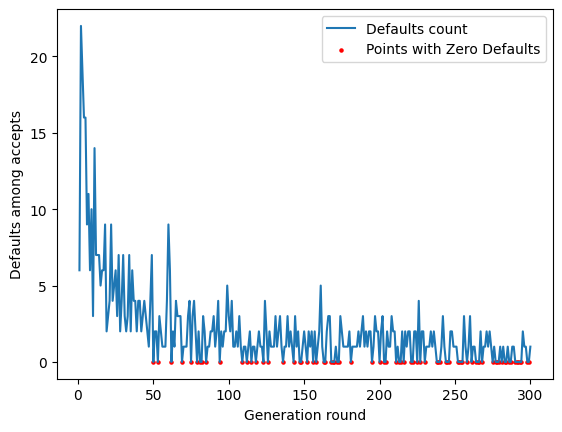

In [3]:
cd_manager.plot_defaults_among_acc("Defaults Among Accepts per round")

In [4]:
rounds_without_defaults = cd_manager.get_round_ids_with_no_defaults_among_acc()
round_to_pick_as_maximal = rounds_without_defaults[(rounds_without_defaults > 100).nonzero()[0,0]].item() - 1
print("Round to pick as maximal:", round_to_pick_as_maximal)

cd_manager.set_maximal_gen_round(round_to_pick_as_maximal)

Round to pick as maximal: 108


In [9]:
from torch import nn
class MomentsCalculator(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(
            self,
            X_r: torch.Tensor,
            mask_r: torch.Tensor,
            X_a: torch.Tensor,
            y_a: torch.Tensor,
            mask_a: torch.Tensor
        ) -> torch.Tensor:
        *b_dims, n_a, F = X_a.shape
        n_r = mask_r.size(-1)
        mask_is_bad = y_a == 1 # [*dims, n_a]

        rbg = 3 # rejects, bads, goods

        max_n = max(n_a, n_r)
        leading_dims = b_dims + [rbg, max_n]
        

        mask_valids = mask_is_bad.new_empty(leading_dims)

        mask_valids[..., 0, :n_r] = mask_r
        mask_valids[..., 1, :n_a] = mask_is_bad & mask_a
        mask_valids[..., 2, :n_a] = ~mask_is_bad & mask_a

        count_valids = mask_valids.sum(dim=-1, keepdim=True) # [*b_dims, rbg, 1]

        X_buffer = X_r.new_empty(leading_dims + [F])
        X_buffer[..., 0, :n_r, :] = X_r
        X_buffer[..., 1:, :n_a, :] = X_a.unsqueeze(-3)


        X_buffer.masked_fill_(~mask_valids.unsqueeze(-1), 0)

        means = X_buffer.sum(dim=-2) / count_valids # [*b_dims, rbg, F]

        vcovs = X_buffer.mT @ X_buffer - count_valids.unsqueeze(-1) * (means.unsqueeze(-1) * means.unsqueeze(-2))

        vcovs /= count_valids.unsqueeze(-1) - 1 

        mask_unique_vcovs = torch.triu(vcovs.new_ones(F, F, dtype=torch.bool))

        proportions = count_valids / count_valids.sum(dim=-2, keepdim=True) # [*b_dims, rbg, 1]

        return torch.cat([
            means, # [*b_dims, rbg, F]
            proportions, # [*b_dims, rbg, 1]
            vcovs[..., mask_unique_vcovs] # [*b_dims, rbg, F*(F+1)/2]
            ], dim=-1) # [*b_dims, rbg, 1 + F*(F+3)/2 = mpc] - mean, proportions, covariance
    
class Actor(nn.Module):
    def __init__(self, F, hidden_dim: int, dtype: torch.dtype, device: torch.device):
        super().__init__()
        rbg = 3
        input_dim = (
            F + # raw features
            rbg * (
                1 + (F * (F+3))//2 # Moments per rbg
            ) 
        )

        self.in_proj = nn.Linear(input_dim, hidden_dim, device=device, dtype=dtype)
        self.layer_norm = nn.LayerNorm(hidden_dim, device=device, dtype=dtype)
        self.gelu = nn.GELU(approximate='tanh')
        self.out_proj = nn.Linear(hidden_dim, 1, device=device, dtype=dtype)
        self.sigmoid = nn.Sigmoid()

    def forward(
            self,
            moments: torch.Tensor,
            X: torch.Tensor,
            logits: torch.Tensor,
            mask: torch.Tensor
        ) -> torch.Tensor:
        *b_dims, N, F = X.shape
        mpc = 1 + F*(F+3)//2
        rgb = 3
        mask_invalid = ~mask
        cat = torch.cat([
            moments # [*b_dims, rbg, 1 + F*(F+3)/2 = mpc]
            .flatten(-2, -1) # [*b_dims, rbg * mpc]
            .unsqueeze(-2)  # [*b_dims, 1, rbg * mpc]
            .expand(*b_dims, N, rgb * mpc)
            ,
            X
        ], dim=-1).masked_fill(mask_invalid.unsqueeze(-1), value=0)

        logits = logits.masked_fill(mask_invalid.unsqueeze(-1), value=0) # [*b_dims, N, 1]
        

        out = self.in_proj(cat)
        out = self.layer_norm(out)
        out = self.gelu(out)
        out = logits + self.out_proj(out) # residual_add

        return self.sigmoid(out) * mask.unsqueeze(-1)




In [10]:
from berebasl.estimation.classifiers import BatchedLogistic

dtype = cd_manager.credit_data.features.dtype
device = cd_manager.device

unsupervised_encoder = MomentsCalculator()
actor = Actor(cd_manager.F, hidden_dim=32, dtype=dtype, device=device)

up_to_gen_samples = torch.tensor([[10, 15, 12], [5, 7, 16]])

sample = cd_manager.generate_credit_sample(up_to_gen=up_to_gen_samples)

mask_valid_lbld = ~sample.labels.isnan()
batched_lr = BatchedLogistic(cd_manager.F, up_to_gen_samples.shape, dtype=dtype, device=device)

batched_lr.fit(sample.features_labeled, sample.labels, mask_valid_lbld)

betas_orig = batched_lr.beta.clone()

moments = unsupervised_encoder(
    X_r = sample.features_unlabeled,
    mask_r = ~sample.features_unlabeled[..., 0].isnan(),
    X_a = sample.features_labeled,
    y_a = sample.labels,
    mask_a = mask_valid_lbld
)

sample_futures = cd_manager.generate_credit_sample(up_to_gen=up_to_gen_samples+1, from_gen = up_to_gen_samples+1)

X_future = torch.cat([sample_futures.features_labeled, sample_futures.features_unlabeled], dim=-2)

mask_valid_future = ~X_future[..., 0].isnan()
actor(moments, X_future, logits=batched_lr(X_future), mask=mask_valid_future)

tensor([[[[0.0704],
          [0.0494],
          [0.0376],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0773],
          [0.0656],
          [0.0523],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0744],
          [0.0095],
          [0.0846],
          ...,
          [0.3809],
          [0.5672],
          [0.3318]]],


        [[[0.0999],
          [0.0362],
          [0.0563],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0799],
          [0.0788],
          [0.0410],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]],

         [[0.0218],
          [0.0610],
          [0.0673],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]]]], dtype=torch.float64, grad_fn=<MulBackward0>)

In [8]:
batched_lr(X_future)

tensor([[[[-2.6276],
          [-3.0010],
          [-3.2825],
          ...,
          [    nan],
          [    nan],
          [    nan]],

         [[-2.5823],
          [-2.7090],
          [-2.8186],
          ...,
          [    nan],
          [    nan],
          [    nan]],

         [[-2.4950],
          [-4.6831],
          [-2.4607],
          ...,
          [-0.6070],
          [ 0.2616],
          [-0.7855]]],


        [[[-2.2259],
          [-3.2924],
          [-2.8493],
          ...,
          [    nan],
          [    nan],
          [    nan]],

         [[-2.4391],
          [-2.4501],
          [-3.2441],
          ...,
          [    nan],
          [    nan],
          [    nan]],

         [[-3.8540],
          [-2.7107],
          [-2.5984],
          ...,
          [    nan],
          [    nan],
          [    nan]]]], dtype=torch.float64)

In [106]:
new_betas

tensor([[[[ 2.0196],
          [-0.5629],
          [-1.8230]],

         [[ 1.9898],
          [-0.5752],
          [-1.7771]],

         [[ 2.0166],
          [-0.5840],
          [-1.7860]]],


        [[[ 1.8058],
          [-0.4787],
          [-1.7543]],

         [[ 1.8802],
          [-0.5130],
          [-1.7663]],

         [[ 2.0022],
          [-0.5779],
          [-1.7823]]]], dtype=torch.float64)